# STEP 0 — Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
    )
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# STEP 1 — Load the Dataset

In [ ]:
df = pd.read_csv('/content/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 1.1 Check Dataset Shape

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


# 1.2 Basic Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# 1.3 Check Missing Values

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# STEP 2 — Preprocessing

# 2.1 Convert TotalCharges to Numeric

In [ ]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce' # coerce enables all the string values in to NaN.
)

# 2.2 Check Missing Values Again

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


# 2.3 Handle Missing TotalCharges

In [ ]:
#We can see here 11 missing values in TotaglCharges, so we need to handle this missing values with median

In [ ]:
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())

In [ ]:
df.isnull().sum().sum()

np.int64(0)

# STEP 3 — Remove Unnecessary ID Column

In [ ]:
df = df.drop('customerID', axis=1)

# STEP 4 — Explore the Target Variable

In [ ]:
#Our Taget variable is Churn

print(df['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
#Adding percentage%
print(df['Churn'].value_counts(normalize=True)*100)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
#Here we are observing a  class imbalance. We can visualize the class distribution

# 4.1 Visualize Churn Distribution

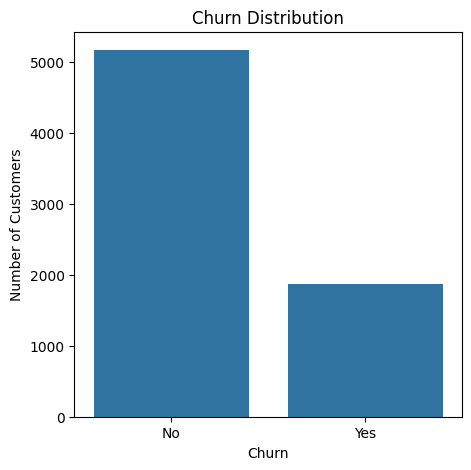

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x=df['Churn'])
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()


Above distribution visual indicates that,  this dataset is imbalance as since we can see that, signifacntly customers did not churn than customer churned. So, a Stratified train test split is used to prserve approximately the same class distribution in both datasets

# STEP 5 — Separate X and y

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [ ]:
#Need to convert the target in to 0 and 1 (It is called Mapping)
y = y.map({'Yes': 1, 'No': 0})

# STEP 6 — Identify Categorical and Numerical Features

In [ ]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
numerical_features = X.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical Features:", categorical_features)
print("Numerical Features:", numerical_features)


Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numerical Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


# STEP 7 — Encode Categorical Variables

In [ ]:
#Decision Tree required numerical inputs so we will use Onehot Encoding

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                drop='first'
            ),
            categorical_features
        )
    ],
    remainder='passthrough'
)

# STEP 8 — Stratified Train-Test Split

In [ ]:
#Stratification is important becasue of the churn imbalance

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Stratify y because withou stratification the dataset may have slightly different distribution churn.
)

In [ ]:
stratify = y #class distribution is approximately preserved.

# Check the Split

In [ ]:
print ("Training set:")
print("X_train.value_counts():", y_train.value_counts(normalize=True))
print("X_test.value_counts():", y_test.value_counts(normalize=True))


Training set:
X_train.value_counts(): Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64
X_test.value_counts(): Churn
No     0.734564
Yes    0.265436
Name: proportion, dtype: float64


# STEP 9 — Baseline Decision Tree

In [ ]:
DecisionTreeClassifier(criterion='gini')

DecisionTreeClassifier()

In [ ]:
#Creating a Pipeline

baseline_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(criterion='gini',random_state=42))
    ]
)

In [ ]:
#Train

baseline_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [ ]:
#Calculate Training Accuracy

train_predictions = baseline_model.predict(X_train)
train_accuracy = accuracy_score(y_train, train_predictions)
print("Training Accuracy:", train_accuracy)

Training Accuracy: 0.9980475683351083


In [ ]:
#Calculate Test Accuracy

test_predictions = baseline_model.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predictions)
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.7423704755145494


# STEP 10 — Demonstrate Overfitting

In [ ]:
print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)

print(
    "Accuracy Gap:",
    train_accuracy - test_accuracy
)

Training Accuracy: 0.9980475683351083
Test Accuracy: 0.7423704755145494
Accuracy Gap: 0.25567709282055895


#Interpretation
# Training_Accuracy = 99.80%
# Test_Accuracy = 74.23%
# Training → almost perfect
# Testing  → much worse

#We can say , this may be the example of overfitting because of the tranining accuracy tried to be almost perfect on the contrary the testing accuracy much worse

# STEP 11 — Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        test_predictions
    )
)

              precision    recall  f1-score   support

          No       0.82      0.83      0.82      1035
         Yes       0.51      0.51      0.51       374

    accuracy                           0.74      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.74      0.74      1409



# We will not depend on this accuracy because the dataset still imbalanced

# STEP 12 — Confusion Matrix

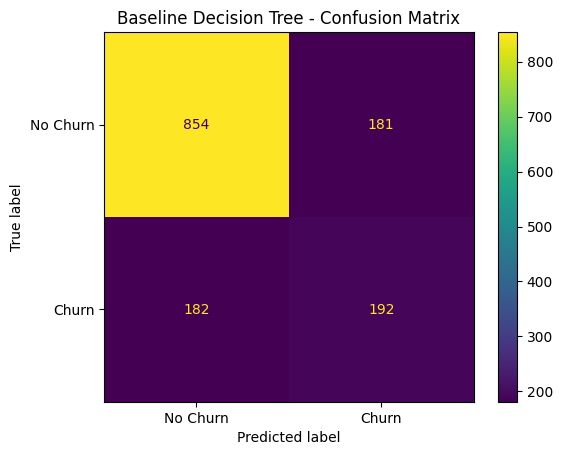

In [ ]:
cm = confusion_matrix(y_test, test_predictions)
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
display.plot()
plt.title('Baseline Decision Tree - Confusion Matrix')
plt.show()

# STEP 13 — Gini vs Entropy

In [ ]:
#13.1 Gini Tree

gini_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(criterion='gini',random_state=42))
    ]
)
gini_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [ ]:
#13.2 Entropy Tree

entropy_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(criterion='entropy',random_state=42))
    ]
)
entropy_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 DecisionTreeClassifier(criterion='entropy', random_state=42))])

# STEP 14 — Compare Accuracy

In [ ]:
gini_train_accuracy = accuracy_score(y_train, gini_model.predict(X_train))
gini_test_accuracy = accuracy_score(y_test, gini_model.predict(X_test))
entropy_train_accuracy = accuracy_score(y_train, entropy_model.predict(X_train))
entropy_test_accuracy = accuracy_score(y_test, entropy_model.predict(X_test))

print("Gini Train Accuracy:", gini_train_accuracy)
print("Gini Test Accuracy:", gini_test_accuracy)

print("Entropy Train Accuracy:", entropy_train_accuracy)
print("Entropy Test Accuracy:", entropy_test_accuracy)

Gini Train Accuracy: 0.9980475683351083
Gini Test Accuracy: 0.7423704755145494
Entropy Train Accuracy: 0.9980475683351083
Entropy Test Accuracy: 0.7366926898509581


# STEP 15 — Compare Tree Depth

In [ ]:
gini_tree = gini_model.named_steps['classifier']
entropy_tree = entropy_model.named_steps['classifier']

print("Gini Tree Depth:", gini_tree.get_depth())
print("Entropy Tree Depth:", entropy_tree.get_depth())

print("Gini Tree Leaf Count:", gini_tree.get_n_leaves())
print("Entropy Tree Leaf Count:", entropy_tree.get_n_leaves())

Gini Tree Depth: 24
Entropy Tree Depth: 31
Gini Tree Leaf Count: 1098
Entropy Tree Leaf Count: 1058


# STEP 16 — Compare Which Feature Was Selected First

In [ ]:
feature_names = (
    gini_model.named_steps['preprocessor'].get_feature_names_out()
)

gini_root_index = gini_tree.tree_.feature[0]
entropy_root_index = entropy_tree.tree_.feature[0]

print(
    "Gini first feature:",
    feature_names[gini_root_index]
)

print(
    "Entropy first feature:",
    feature_names[entropy_root_index]
)

Gini first feature: remainder__tenure
Entropy first feature: cat__Contract_Two year


# Gini and Entropy use different impurity measurements, so they can select different features or split points, although they may often produce similar trees.

# STEP 17 — GridSearchCV Hyperparameter Tuning

# max_depth:
[3, 5, 7, 10, None]

# min_samples_split:
[2, 10, 20, 50]

# min_samples_leaf:
[1, 5, 10, 20]

# criterion:
# ['gini', 'entropy']

# 17.1 Create Pipeline

In [ ]:
dt_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]
)

# STEP 18 — Define Parameter Grid

In [ ]:
param_grid = {
    'classifier__max_depth': [
        3, 5, 7, 10, None
    ],

    'classifier__min_samples_split': [
        2, 10, 20, 50
    ],

    'classifier__min_samples_leaf': [
        1, 5, 10, 20
    ],

    'classifier__criterion': [
        'gini',
        'entropy'
    ]
}

# STEP 19 — Run GridSearchCV

In [61]:
grid_search = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          'DeviceProtection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('classifier',
                                        DecisionTreeClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__criterion': ['gini', 'entropy'],
                         'classifier__max_depth': [3, 5, 7, 10, None],
                         'classifier__min_samples_leaf': [1, 5, 10, 20],
                         'classifier__min_samples_split': [2, 10, 20, 50]},
             return_train_score=True, scoring='accuracy')

# STEP 20 — Best Parameters

In [62]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__criterion': 'entropy', 'classifier__max_depth': 7, 'classifier__min_samples_leaf': 20, 'classifier__min_samples_split': 2}


# STEP 21 — Evaluate Best Model on Test Set

In [63]:
best_model = grid_search.best_estimator_

best_test_pred = best_model.predict(X_test)

best_test_accuracy = accuracy_score(
    y_test,
    best_test_pred
)

print(
    "Test Accuracy:",
    best_test_accuracy
)

Test Accuracy: 0.8019872249822569


# STEP 22 — Compare Baseline vs Tuned Tree

In [64]:
print("Baseline Test Accuracy:",
      test_accuracy)

print("Tuned Test Accuracy:",
      best_test_accuracy)

best_tree = best_model.named_steps['classifier']

print(
    "Baseline depth:",
    gini_tree.get_depth()
)

print(
    "Tuned depth:",
    best_tree.get_depth()
)

Baseline Test Accuracy: 0.7423704755145494
Tuned Test Accuracy: 0.8019872249822569
Baseline depth: 24
Tuned depth: 7


# STEP 23 — Cost Complexity Pruning


In [67]:
X_train_processed = (
    preprocessor.fit_transform(X_train)
)

X_test_processed = (
    preprocessor.transform(X_test)
)

# STEP 24 — Create an Unpruned Tree for Pruning Path

In [69]:
pruning_tree = DecisionTreeClassifier(
    criterion='gini',
    random_state=42
)

pruning_tree.fit(X_train_processed, y_train)

DecisionTreeClassifier(random_state=42)

# STEP 25 — Extract Alpha Values

In [71]:
path = pruning_tree.cost_complexity_pruning_path(
    X_train_processed,
    y_train
)

alphas, impurities = path.ccp_alphas, path.impurities